### **OBBA MARK CALVIN S23B23/047 B24277**
## MNIST Autoencoder using TensorFlow
An autoencoder is implemented using TensorFlow/Keras on the MNIST handwritten digits dataset. The goal is to train the model to compress input images into a smaller latent representation and then reconstruct them as closely as possible. This satisfies the assignment’s requirement to implement one generative model and include the architecture, training process, output samples, and observations.

## 3. Explanation of the model architecture

**Autoencoder structure**

The Autoencoder has two main parts:

**Encoder**

- Input layer: 784 neurons, representing the flattened 28 × 28 MNIST image
- Hidden layer 1: 128 neurons with ReLU activation
- Hidden layer 2: 64 neurons with ReLU activation
- Latent layer: 32 neurons with ReLU activation

Decoder

- Hidden layer 1: 64 neurons with ReLU activation
- Hidden layer 2: 128 neurons with ReLU activation
- Output layer: 784 neurons with sigmoid activation

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np


# 1. Load and preprocess data

In [2]:
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

In [3]:
# Normalize pixel values to [0,1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten 28x28 images into vectors of size 784
x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

print("Training shape:", x_train.shape)
print("Testing shape:", x_test.shape)

Training shape: (60000, 784)
Testing shape: (10000, 784)


# 2. Define Autoencoder architecture

In [4]:
input_dim = 784
encoding_dim = 32

# Encoder
input_img = layers.Input(shape=(input_dim,))
encoded = layers.Dense(128, activation='relu')(input_img)
encoded = layers.Dense(64, activation='relu')(encoded)
latent = layers.Dense(encoding_dim, activation='relu', name="latent_space")(encoded)

# Decoder
decoded = layers.Dense(64, activation='relu')(latent)
decoded = layers.Dense(128, activation='relu')(decoded)
output_img = layers.Dense(input_dim, activation='sigmoid')(decoded)

# Autoencoder model
autoencoder = models.Model(input_img, output_img)

# Separate encoder model
encoder = models.Model(input_img, latent)

# Decoder model
latent_input = layers.Input(shape=(encoding_dim,))
decoder_layer1 = autoencoder.layers[-3](latent_input)
decoder_layer2 = autoencoder.layers[-2](decoder_layer1)
decoder_output = autoencoder.layers[-1](decoder_layer2)
decoder = models.Model(latent_input, decoder_output)

# Compile the model
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Show model summary
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (Dense)            │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,384 (868.69 KB)

 Trainable params: 222,384 (868.69 KB)

 Non-trainable params: 0 (0.00 B)

# 3. Train the model

In [5]:
history = autoencoder.fit(
    x_train, x_train,
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test)
)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - loss: 0.2461 - val_loss: 0.1664
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1487 - val_loss: 0.1349
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.1303 - val_loss: 0.1238
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.1215 - val_loss: 0.1171
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.1151 - val_loss: 0.1118
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - loss: 0.1102 - val_loss: 0.1067
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1066 - val_loss: 0.1038
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1039 - val_loss: 0.1020
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 0.1016 - val_loss: 0.0999
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0997 - val_loss: 0.0978
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0982 - val_loss: 0.0967
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━

# 4. Reconstruct test images

In [6]:
# Reconstruct test images

decoded_imgs = autoencoder.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


# 5. Plot training and validation loss

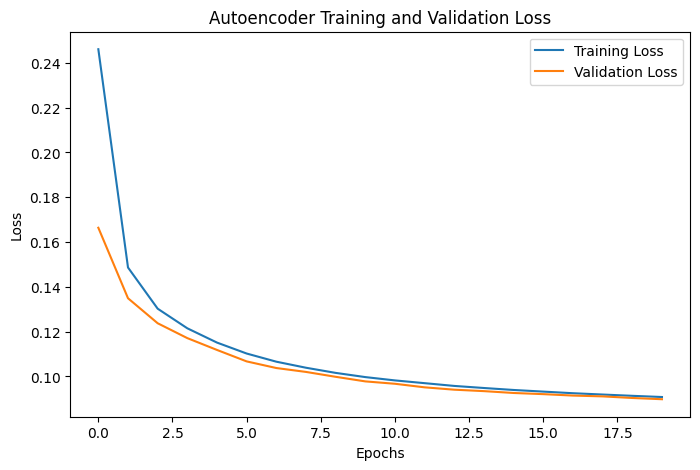

In [7]:
# 5. Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Autoencoder Training and Validation Loss')
plt.legend()
plt.show()

# 6. Display original vs reconstructed images

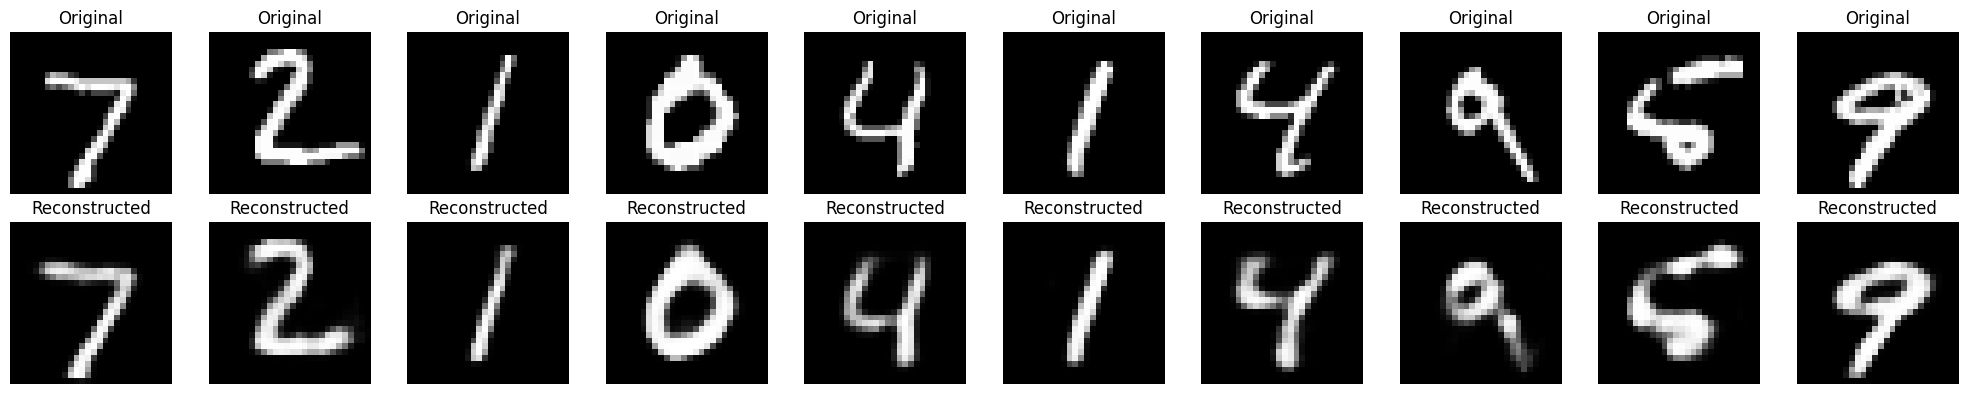

In [8]:
n = 10
plt.figure(figsize=(20, 4))

for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Reconstructed
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.tight_layout()
plt.show()

# 7. Visualize compressed latent features

In [9]:
encoded_imgs = encoder.predict(x_test[:10])
print("Encoded representation shape:", encoded_imgs.shape)
print(encoded_imgs[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step
Encoded representation shape: (10, 32)
[ 6.292077  15.542185  13.782774  14.897484  10.081436   3.1202562
  0.        11.060278   0.         7.6718783 10.805211  13.466717
 18.097477  12.546716   7.4124947  4.5913477  6.4480643 19.984732
  0.        10.256315   0.         9.368156   9.571777   2.2546432
  9.956303  13.15189    6.8493714  0.        11.348218  11.336833
 10.54468   18.895882 ]


# Output Samples

After training the Autoencoder on the MNIST dataset, the model was able to reconstruct handwritten digit images with a reasonable level of accuracy. The reconstructed images were visually similar to the original inputs, although some appeared slightly blurred and less sharp than the originals. This is expected because the Autoencoder compresses the images into a low-dimensional latent space before reconstructing them.

The comparison between original and reconstructed images shows that the model successfully learned the key structural features of handwritten digits, such as curves, edges, and general shape. Digits with simpler structures were reconstructed more clearly, while more complex digits sometimes lost finer details.

# Observations
- The Autoencoder successfully learned how to compress and reconstruct MNIST digit images, showing that it captured the important features of the dataset.
- As training progressed, both training loss and validation loss decreased, indicating that the model improved its reconstruction ability over time.
- The reconstructed images were generally recognizable, but they were not perfectly identical to the original images. Some fine details were lost due to compression in the latent space.
- The latent dimension of 32 provided a strong compression ratio, reducing the original 784 input features to only 32 while still preserving enough information to reconstruct the digit.
- The model performed better on clearly written digits and slightly worse on ambiguous or poorly shaped digits.
- One limitation observed is that the Autoencoder reconstructs existing patterns well, but it is not as strong as models like VAEs or GANs when it comes to generating highly diverse new samples.
- The experiment demonstrated that Autoencoders are effective for dimensionality reduction, feature learning, and image reconstruction tasks

# Conclusion

The TensorFlow-based Autoencoder implemented on the MNIST dataset demonstrated the ability to learn compressed representations of handwritten digits and reconstruct them with good accuracy. The experiment showed how encoder-decoder networks can perform unsupervised feature learning and dimensionality reduction. Although the reconstructed outputs were slightly blurred, the model was effective in preserving the main digit structures, making it suitable for representation learning and reconstruction tasks.